# Méthodes de gradient (II)

## Méthode de gradient à pas optimal
Dans la méthode de gradient à pas optimal, le pas est variable. À chaque itération, on choisit le pas qui permet de faire décroitre la fonction $F$ le plus possible : 
$$v_{k+1} = v_k - \varrho^{}_k \nabla F(v_k) \text{où} \varrho^{}_k = \arg\min_{\varrho > 0} F(v_k - \varrho \nabla F(v_k))$$

### Exercice 1 : Gradient à pas optimal.

- Montrer que si le pas optimal $\varrho^{}_k$ existe alors il vérifie :
  $$ \langle \nabla F(v_k),\nabla F\big(v_k-\varrho^{}_k \nabla F(v_k)\big)\rangle = 0 $$


#### votre réponse ici


- On s'intéresse au cas $F(x,y) = ax^2 + by^2$, avec $a,b \in {\mathbb R}$. 
En déduire que pour tout $k \in {\mathbb N}$ :
$$\varrho^{}_k = \dfrac{a^2 x_k^2 + b^2 y_k^2}{2(a^3 x_k^2 + b^3 y_k^2)}$$

#### votre réponse ici


- Ecrire une fonction qui implémente la méthode de gradient à pas optimal dans le cas considéré ici (utiliser la question précédente) : `gopt(GradF, v0, tol, NitMax)` où, 

-  `GradF` est une fonction qui calcule le gradient de $F$ au point $v = (x,y)$,

-  `v0` le point initial,

-  `tol` la tolérance demandée qui servira pour le critère d'arrêt,

-  `NitMax` le nombre maximal d'itérations autorisé,

Cette fonction retourne 

-  le minimum trouvé,

-  la suite des itérés $v_k = (x_k, y_k)_k$,

- le nombre d'itération pour atteindre la tolérance demandée,

- une variable booléenne qui prend la valeur `True` si la méthode a convergé et `False` sinon.

In [45]:
import numpy as np
import math

np.array([2.*7,np.pi**2])

def pas_optimal(x_k,y_k,a,b):
    return ((a*x_k)**2+(b*y_k)**2)/(2*(a**3*x_k**2+b**3*y_k**2))


def GradF(x,y,a,b):
    return np.array([2*a*x,2*b*y])

def gopt(GradF,v0,tol,NitMax):
    converged = False
    iterates = [np.array(v0)]
    v = v0.copy()

    for it in range(NitMax):
        (x_k,y_k) = v
        gf = GradF(x_k,y_k,a,b)
        v = v - pas_optimal(x_k,y_k,a,b)*GradF(x_k,y_k,a,b)
    
        iterates.append(v)

 
        if np.linalg.norm(gf) < tol:
            print("<tol")
            converged
            break
    return v, iterates, it, converged




- Tester votre code avec la fonction $F(x,y) = x^2 + 100 y^2$, avec pour initialisation $v_0= (1,1)$ puis $v_0= (0, \sqrt{2})$. Que constatez vous ? 

In [72]:
#### votre réponse ici
a=1
b=100

v, iterates, it, converged = gopt(GradF,np.array([1,1]), (2.7)**(-6), 1000 )

print(iterates)
print(v[-1])

v, iterates, it, converged = gopt(GradF,np.array([0,math.sqrt(2)]), (2.7)**(-6), 10 )


print(iterates)


<tol
[array([1, 1]), array([ 9.8999901e-01, -9.8999901e-05]), array([0.00970395, 0.00970395]), array([ 9.60690158e-03, -9.60690158e-07]), array([9.4166659e-05, 9.4166659e-05]), array([ 9.32248992e-05, -9.32248992e-09]), array([9.13788616e-07, 9.13788616e-07])]
9.13788616113484e-07
<tol
[array([0.        , 1.41421356]), array([0.00000000e+00, 2.22044605e-16]), array([0., 0.])]


- Comparer les résultats avec ceux obtenus avec la méthode le gradient à pas fixe.

In [69]:
#### votre réponse ici

rho = 3

def gf(GradF,v0,tol,NitMax):
    converged = False
    iterates = [np.array(v0)]
    v = v0.copy()

    for it in range(NitMax):
        print(it)
        (x_k,y_k) = v
        gf = GradF(x_k,y_k,a,b)
        v = v - rho*GradF(x_k,y_k,a,b)

        iterates.append(v)

 
        if np.linalg.norm(gf) < tol:
            print("<tol")
            converged
            break
    return v, iterates, it, converged


v, iterates, it, converged = gf(GradF,np.array([0,math.sqrt(2)]), (2.7)**(-6), 10 )

print(iteres)

v, iterates, it, converged = gf(GradF,np.array([1,1]), 1e-16, 10 )


0
1
2
3
4
5
6
7
8
9
[array([1, 1]), array([  -5, -599]), array([    25, 358801]), array([      -125, -214921799]), array([         625, 128738157601]), array([          -3125, -77114156402999]), array([            15625, 46191379685396401]), array([              -78125, -9221892357842892583]), array([             390625, 8337044308736724033]), array([           -1953125, 5178103041990792169]), array([             9765625, -2630717769279837743])]
0
1
2
3
4
5
6
7
8
9


/tmp/ipykernel_3243/1754821691.py:11: RuntimeWarning: overflow encountered in scalar multiply
  return np.array([2*a*x,2*b*y])


### Exercice 2. 

On considère la fonction $f$ définie pour tout $v=(v_1,v_2) \in {\mathbb R}^2$ par
$$
f(v) = (v_1 - 4)^2 + 2(v_2 - 3)^2 + v_1v_2.
$$


- Montrer que $f$ admet un unique minimiseur sur $\mathbb{R}^2$ et le déterminer.

#### votre réponse ici


- Implémenter la fonction $f$ qui prend en argument un vecteur `numpy` de taille $2$, représentant un point $v$ de ${\mathbb R}^2$, et qui retourne la valeur de la fonction $f$ en ce point.

In [81]:
#### votre réponse ici
import matplotlib.pyplot as plt

def f(v):
    return (v[0]-4)**2 + 2*(v[1]-3)**2 + v[0]*v[1]

- Tracer les lignes de niveaux de $f$.

<a list of 8 text.Text objects>

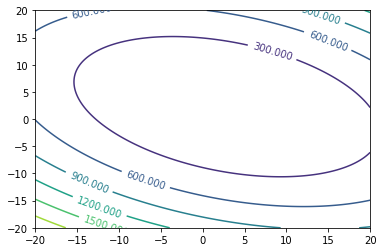

In [87]:
#### votre réponse ici

x = np.linspace(-20,20,1000)
y = np.linspace(-20,20,1000)
X,Y  = np.meshgrid(x,y)
v = np.array([X,Y])
Z = f(v)

dessin = plt.contour(X,Y,Z)
plt.clabel(dessin,fmt='%.3f',inline = True)



- Implémenter la fonction `gradf` qui calcule le gradient de $f$ en un point.

In [88]:
#### votre réponse ici

def gradf(v):
    return np.array([2*(v[0]-4)+v[1],4*(v[1]-3)+v[0]])

- On rappelle que dans la méthode de gradient à pas optimal, le pas $\varrho^{}_n$ change à chaque itération :
		$$v_{n+1} = v_n - \varrho^{}_n \nabla f(v_n) \text{où} \varrho^{}_n = \arg\min_{\varrho > 0} f(v_n - \varrho \nabla f(v_n))$$
Posons $g_n(\varrho) = f(v_n - \varrho \nabla f(v_n))$, définie de ${\mathbb R}$ dans ${\mathbb R}$. A chaque itération, pour déterminer le pas optinal $\varrho^{}_n$, nous cherchons la solution du problème (possiblement non linéaire) suivant :
$$g_n'(\varrho) = 0$$

Montrer, pour tout $n \geq 0$, que la dérivée de $g_n$ est

$$
\forall \varrho \in {\mathbb R} g^\prime_n(\varrho) = - \nabla f(v_n) \cdot \nabla f(v_n - \varrho \nabla f(v_n)).
$$

#### votre réponse ici


- Implémenter une fonction `gprime` qui prend en arguments un réel $\varrho$, la fonction `gradf` et un point $v \in {\mathbb R}^2$ (vecteur `numpy` de taille 2) et qui retourne la valeur $g'(\varrho)$ qui dépend de $v$ et $\nabla f(v)$.

In [7]:
#### votre réponse ici


## Pour aller plus loin
Dans le cas général, il est difficile de calculer le pas optimal explicitement. Lorsque la fonction objectif $J$ est deux fois différentiable, 
la formule de Taylor permet d'écrire au voisinage de $v_k$
$$J(v) \approx \underbrace{ J(v_k) + \langle \nabla J(v_k), v-v_k \rangle + \frac12 \langle \text{Hess} J(v_k) (v-v_k),v-v_k \rangle}_{\displaystyle \tilde J_{v_k}(v)}.$$

On notera que la fonction $\tilde J_{v_k}$ est une fonction quadratique. Dans ce cas, au lieu de calculer le pas optimal pour la fonction $J$, on se contente de calculer le pas optimal pour la fonction $\tilde J_{v_k}$, de sorte que la méthode du gradient à pas optimal devient
$$
\begin{array}{l}
\tilde \varrho^{}_{k\hphantom{+1}} \in \displaystyle\arg\min_{\varrho \in {\mathbb R}} \tilde J_{v_k}\big(v_k-\varrho \nabla J(v_k)\big)\\
v_{k+1} = v_k-\tilde \varrho^{}_k \nabla J(v_k)
\end{array}
$$

### Exercice 3. Cas non quadratique.
On s'intéresse au cas $J(x,y) = (x + 2 y)^4$.

- Tracer quelques lignes de niveau de la fonction $J$.

In [8]:
#### votre réponse ici


- Montrer que pour tout $(x, y) \in {\mathbb R}^2$,
$$
\nabla J(x,y) = \begin{pmatrix}
4 (x+2 y)^3\\
8 (x+2 y)^3\\
\end{pmatrix} 
= 4(x+2 y)^3 \begin{pmatrix} 1\\
2 \end{pmatrix}
$$
et 
$$
\text{Hess} J(x,y) = \begin{pmatrix}
12 (x+2 y)^2&24(x+2 y)^2\\
24 (x+2 y)^2&48(x+2 y)^2
\end{pmatrix} 
= 12 (x+2 y)^2 \begin{pmatrix} 1 & 2 \\
2 & 4 \end{pmatrix}.
$$

- Montrer que le pas optimal vaut, pour tout $k\in{\mathbb N}$ tel que $x_k+2 y_k\neq 0$,
$$\varrho^{}_k = \frac{1}{20 (x_k+2 y_k)^2}.$$

- Montrer que le pas optimal approché vaut, pour tout $k\in{\mathbb N}$ tel que $x_k+2 y_k\neq 0$,
$$\tilde\varrho^{}_k = \frac{1}{120 (x_k+2 y_k)^2}.$$

In [9]:
#### votre réponse ici

- Programmer la méthode du gradient à pas optimal avec les pas exact $\varrho^{}_k$ et approché $\tilde\varrho^{}_k$. On choisira comme initialisation $(x_0,y_0) = (1,1)$. Comparer les résultats et le nombre d'itérations.

In [10]:
#### votre réponse ici



- Programmer la méthode de Barzilai Borwein 
$$x_{k+1}=x_k-\rho_k\nabla f(x_k),\quad\mbox{où } \rho_k=\dfrac{\langle y_{k-1},s_{k-1}\rangle}{|\!|{ y_{k-1}}|\!|^2},$$
avec $$y{k-1} = \nabla f(x_k)-\nabla f(x_{k-1}),\mbox{ et }s_{k-1}=x_k-x_{k-1}.$$


- Pour cette fonction, comment fonctionne la méthode de gradient à pas fixe (prendre `rho = 0.01` et `NitMax=6000`)? Comparer le nombre d'itérations de chaque méthode.